# B20 — Interference and Phase Kickback in Qiskit

**Track B — the SDK.** A08 built interference out of complex numbers you could
add on paper. This notebook builds the same physics out of `QuantumCircuit`
objects, measures it with `SamplerV2` shot by shot, and then breaks it with a
noise channel.

---

## The one-sentence version

Put a qubit into a superposition, delay one branch by a phase $\varphi$, bring
the branches back together, and the probability of measuring 0 becomes
$\cos^2(\varphi/2)$ — a **fringe**. Everything else here is that one sentence
with something interesting supplying the $\varphi$, or something unpleasant
taking it away.

The circuit is three lines:

```python
qc.h(0)        # split
qc.p(phi, 0)   # delay one branch
qc.h(0)        # recombine
```

In atomic physics that sequence is a **Ramsey experiment**; in optics it is a
Mach–Zehnder interferometer; on a superconducting chip it is how you calibrate a
qubit's frequency and measure its $T_2$. It is also, structurally, the innermost
loop of phase estimation, Deutsch–Jozsa and Grover.

## The thing that makes it an algorithm

A phase is useless until something *writes* into it. **Phase kickback** is the
write mechanism: apply a controlled-$U$ whose target already sits in an
eigenstate of $U$, and the eigenvalue's phase appears on the **control** —
the qubit the gate was only supposed to be reading. The target does not move.

In the SDK that is one gate, `qc.cp(theta, 0, 1)`, and Qiskit's spelling of it
contains a small shock we will make a point of: `cp` is **symmetric in its
arguments**. `cp(theta, 0, 1)` and `cp(theta, 1, 0)` are the same matrix. There
is no fact of the matter about which qubit is the control — which is exactly why
the phase can land on "the wrong one".

## What this notebook builds

1. The **Ramsey interferogram**: the fringe as an exact `Statevector` curve, with
   `SamplerV2` counts and honest binomial error bars on top.
2. **Phase kickback** in Qiskit, read off the control's reduced density matrix
   with `partial_trace`, and shown on the Bloch sphere.
3. **Kickback as a measuring instrument**: recover $\theta$ from a sampled
   fringe, and watch the recovery degrade as the target is moved off the
   eigenstate.
4. The **8-path waterfall** from A08 Figure 3, rebuilt as a 3-qubit circuit.
5. **Dephasing**, three ways — an explicit `rz`-jitter ensemble, the same thing
   as Aer's `phase_damping_error` channel, and real noisy shots — all landing on
   the same contrast envelope $e^{-\sigma^2/2}$.

## What Track A already gave us

| A08 | here |
|---|---|
| $H \to P(\varphi) \to H$ as a $2\times2$ matrix product | `qc.h(0); qc.p(phi, 0); qc.h(0)` |
| sum over two paths, added head to tail | `Statevector(qc).data` |
| $P(0) = \cos^2(\varphi/2)$, exact | the same curve, plus shot noise |
| controlled-$U$ on an eigenstate, by hand | `qc.cp(theta, 0, 1)` |
| the control's reduced Bloch vector, reshaped by hand | `partial_trace(sv, [1])` |
| ensemble average over Gaussian phase kicks | `phase_damping_error(1 - e^{-\sigma^2})` |
| contrast $= e^{-\sigma^2/2}$ | measured from counts, with error bars |

The checkpoint at the bottom rebuilds A08's interferometer, its N-slit formula
and its dephasing envelope in raw NumPy, and asserts them against what Qiskit
returned.

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.circuit.library import CPhaseGate, PhaseGate
from qiskit.quantum_info import (Kraus, Operator, Statevector, partial_trace)
from qiskit_aer.noise import NoiseModel, phase_damping_error

style.use()

SEED = backends.seed_for("B20")
rng = np.random.default_rng(SEED)

SHOTS = 4096

print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260824


---

## Part 1 — the Ramsey circuit

Three gates, one qubit. `h` splits, `p` delays, `h` recombines.

`p(phi)` is `PhaseGate`: $\mathrm{diag}(1, e^{i\varphi})$. It is **not** `rz(phi)`,
which is $\mathrm{diag}(e^{-i\varphi/2}, e^{+i\varphi/2})$ — the two differ by a
global phase $e^{-i\varphi/2}$, which no measurement anywhere can see, so either
one produces exactly the same fringe. We use `p` because A08's matrix was
$\mathrm{diag}(1, e^{i\varphi})$ and the checkpoint compares amplitudes, not just
probabilities, and amplitudes *do* see the global phase.

Two paths reach the output: through the intermediate $|0\rangle$ (no delay) and
through $|1\rangle$ (delayed by $\varphi$). A08 added them head to tail; here we
just ask `Statevector` for the answer and check it against
$\tfrac12(1 \pm e^{i\varphi})$.

In [2]:
def ramsey(phi):
    """H - P(phi) - H on one qubit. No measurement: for Statevector."""
    qc = QuantumCircuit(1, name="ramsey")
    qc.h(0)
    qc.p(phi, 0)
    qc.h(0)
    return qc


def ramsey_measured(phi):
    """The same circuit with an explicit classical register named "c".

    The register's NAME is how a V2 result is addressed:
    ``result[k].data.c.get_counts()``. ``measure_all()`` would have called it
    "meas" and every access below would be an AttributeError.
    """
    qr, cr = QuantumRegister(1, "q"), ClassicalRegister(1, "c")
    qc = QuantumCircuit(qr, cr)
    qc.h(0)
    qc.p(phi, 0)
    qc.h(0)
    qc.measure(0, 0)
    return qc


print(ramsey_measured(np.pi / 3))

# p(phi) and rz(phi) differ by a global phase and by nothing else.
p_mat = Operator(PhaseGate(0.7)).data
rz_qc = QuantumCircuit(1)
rz_qc.rz(0.7, 0)
rz_mat = Operator(rz_qc).data
print("\nP(0.7)  diag:", np.round(np.diag(p_mat), 6))
print("Rz(0.7) diag:", np.round(np.diag(rz_mat), 6))
print("P == exp(i*0.7/2) * Rz ?",
      np.allclose(p_mat, np.exp(1j * 0.35) * rz_mat))

print(f"\n{'phi/pi':>7} {'a(0)':>22} {'a(1)':>22} {'P(0)':>8}")
for phi in [0.0, np.pi / 3, np.pi / 2, 2 * np.pi / 3, np.pi]:
    sv = Statevector(ramsey(phi)).data
    print(f"{phi/np.pi:7.3f} {sv[0]:>22.4f} {sv[1]:>22.4f} "
          f"{abs(sv[0])**2:8.4f}")

# The two-path sum, written out: a_0 = (1 + e^{i phi})/2, a_1 = (1 - e^{i phi})/2.
for phi in rng.uniform(0, 2 * np.pi, 5):
    sv = Statevector(ramsey(phi)).data
    assert np.allclose(sv, [(1 + np.exp(1j * phi)) / 2,
                            (1 - np.exp(1j * phi)) / 2])
    assert np.isclose(abs(sv[0]) ** 2, np.cos(phi / 2) ** 2)
print("\nStatevector == the two-path sum == cos^2(phi/2).  All three agree.")

     ┌───┐┌────────┐┌───┐┌─┐
  q: ┤ H ├┤ P(π/3) ├┤ H ├┤M├
     └───┘└────────┘└───┘└╥┘
c: 1/═════════════════════╩═
                          0 

P(0.7)  diag: [1.      +0.j       0.764842+0.644218j]
Rz(0.7) diag: [0.939373-0.342898j 0.939373+0.342898j]
P == exp(i*0.7/2) * Rz ? True

 phi/pi                   a(0)                   a(1)     P(0)
  0.000         1.0000+0.0000j         0.0000+0.0000j   1.0000
  0.333         0.7500+0.4330j         0.2500-0.4330j   0.7500
  0.500         0.5000+0.5000j         0.5000-0.5000j   0.5000
  0.667         0.2500+0.4330j         0.7500-0.4330j   0.2500
  1.000         0.0000+0.0000j         1.0000-0.0000j   0.0000

Statevector == the two-path sum == cos^2(phi/2).  All three agree.


### The circuit, drawn

Qiskit's own drawer, on our surface colour. Note the wiring: `style.qiskit_grid`
switches the constrained-layout engine off before the drawer runs, because every
`qiskit.visualization` plotter calls `fig.tight_layout()` internally and the two
layout engines fight — panels overflow and the gate boxes clip.

C:\Users\thoma\quantum-under-the-hood\qviz\style.py:263: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(**adjust)


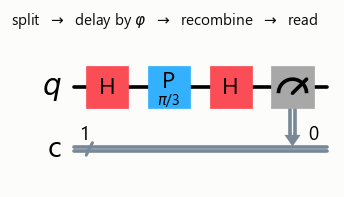

In [3]:
fig, ax = plt.subplots(figsize=(5.6, 1.75))
style.qiskit_grid(fig, left=0.015, right=0.985, top=0.80, bottom=0.02)
ramsey_measured(np.pi / 3).draw("mpl", ax=ax,
                                style={"backgroundcolor": style.SURFACE})
# Qiskit writes the CENTRED title artist; our rcParams default to left, so both
# would render on top of each other unless the centred one is cleared first.
ax.set_title("", loc="center")
ax.set_title(r"split  $\rightarrow$  delay by $\varphi$  $\rightarrow$  "
             r"recombine  $\rightarrow$  read", loc="left", fontsize=10)
plt.show()

## Figure 1 — the interferogram

**Top strip.** The output state at eight values of $\varphi$, in the repo's
amplitude bars: height is $|$amplitude$|$, hue is the phase, and the little clock
hand is the same phase drawn as an angle. Watch the two bars trade height while
the hues rotate.

**Bottom.** The fringe. The blue line is `Statevector` — exact, no sampling. The
orange points are `SamplerV2` at 4096 shots per angle, with the binomial error
bar $\sigma = \sqrt{p(1-p)/N}$ that A04 derived. The grey dashed line at 0.5 is
what a classical coin does for *every* $\varphi$: the phase would be invisible,
because there would be nothing to add it to.

At 4096 shots the individual error bars are smaller than the markers, so the
shape of the noise is drawn as a shaded band instead — **magnified 40×**, and
labelled as such, because the honest version is invisible. The magnification is
the only dishonest thing in the panel and it changes no number.

The band's shape is the point. It **pinches to nothing at $\varphi = 0$ and
$2\pi$** — at a fringe maximum the outcome is deterministic, so there is no
binomial variance left to have — and it is **fattest at $\varphi = \pi/2$ and
$3\pi/2$**, where $p = 1/2$. That is where a fringe is noisiest to measure and
also where it is steepest, and Part 3 shows those two effects cancelling exactly.

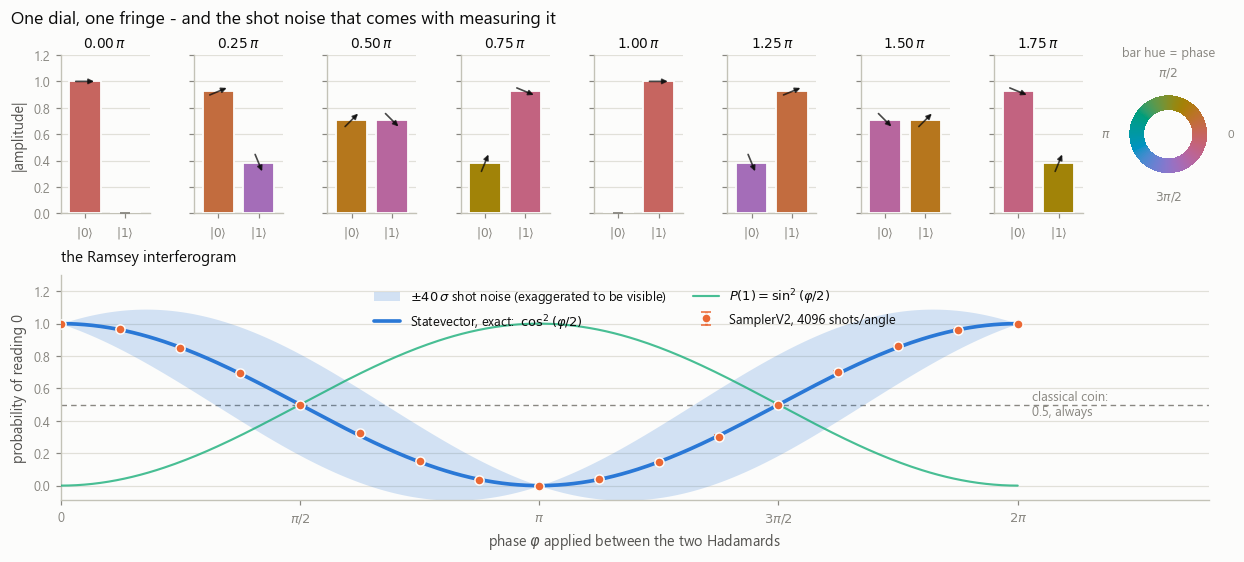

largest |sampled - exact| over the 17 angles: 0.01678
in units of the point's own sigma: 2.29 sigma
error bar at phi = 0 (a deterministic outcome): 0.000000
error bar at phi = pi/2 (p = 1/2):  0.007812   (sqrt(1/(4N)) = 0.007812)


In [4]:
PHI_FRAMES = np.linspace(0, 2 * np.pi, 8, endpoint=False)
PHI_DENSE = np.linspace(0, 2 * np.pi, 361)
P_DENSE = np.array([Statevector(ramsey(p)).probabilities()[0]
                    for p in PHI_DENSE])


def sampled_fringe(phis, *, shots=SHOTS, seed=SEED, noise_model=None,
                   circuit=ramsey_measured):
    """P(0) and its binomial 1-sigma at each phi, from real counts.

    One sampler call, one pub per angle. ``.data.c`` is the classical
    register's name; getting that wrong is an AttributeError at runtime.
    """
    sampler = backends.sampler(shots=shots, seed=seed, noise_model=noise_model)
    res = sampler.run([circuit(p) for p in phis]).result()
    p0 = np.array([res[k].data.c.get_counts().get("0", 0) / shots
                   for k in range(len(phis))])
    return p0, np.sqrt(p0 * (1 - p0) / shots)


PHI_PTS = np.linspace(0, 2 * np.pi, 17)
p0_pts, sig_pts = sampled_fringe(PHI_PTS)

fig = plt.figure(figsize=(11.2, 5.0))
gs = fig.add_gridspec(2, 9, height_ratios=[0.95, 1.35],
                      width_ratios=[1] * 8 + [0.92])

for j, phi in enumerate(PHI_FRAMES):
    ax = fig.add_subplot(gs[0, j])
    grid.amp_bars(ax, Statevector(ramsey(phi)).data, labels=["0", "1"],
                  ylim=1.20)
    ax.set_title(rf"${phi/np.pi:.2f}\,\pi$", loc="center", fontsize=9, pad=5)
    if j:
        ax.set_ylabel("")
        ax.set_yticklabels([])

axw = fig.add_subplot(gs[0, 8], projection="polar")
style.phase_wheel(axw, label="bar hue = phase")

axc = fig.add_subplot(gs[1, :])
axc.axhline(0.5, color=style.MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)
# At 4096 shots the individual error bars are sub-pixel. The band is the same
# quantity drawn continuously, and it makes the phi-dependence of the noise -
# fat at the half-height points, pinched to nothing at the peaks - visible.
band = 40 * np.sqrt(P_DENSE * (1 - P_DENSE) / SHOTS)
axc.fill_between(PHI_DENSE, P_DENSE - band, P_DENSE + band, color=style.BLUE,
                 alpha=0.20, lw=0, zorder=2,
                 label=r"$\pm 40\,\sigma$ shot noise (exaggerated to be visible)")
axc.plot(PHI_DENSE, P_DENSE, color=style.BLUE, lw=2.4, zorder=4,
         label=r"Statevector, exact:  $\cos^2(\varphi/2)$")
axc.plot(PHI_DENSE, 1 - P_DENSE, color=style.AQUA, lw=1.4, alpha=0.8, zorder=3,
         label=r"$P(1) = \sin^2(\varphi/2)$")
axc.errorbar(PHI_PTS, p0_pts, yerr=sig_pts, ls="none", marker="o", ms=6.0,
             color=style.ORANGE, markeredgecolor=style.SURFACE,
             markeredgewidth=1.0, elinewidth=1.7, capsize=3.5, zorder=6,
             label=f"SamplerV2, {SHOTS} shots/angle")
axc.text(2 * np.pi * 1.015, 0.5, "classical coin:\n0.5, always", va="center",
         fontsize=8.5, color=style.MUTED)
axc.set_xlim(0, 2 * np.pi * 1.20)
axc.set_ylim(-0.09, 1.30)
axc.set_xticks(np.linspace(0, 2 * np.pi, 5))
axc.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axc.set_xlabel(r"phase $\varphi$ applied between the two Hadamards")
axc.set_ylabel("probability of reading 0")
axc.legend(loc="upper center", ncols=2, fontsize=8.5)
axc.set_title("the Ramsey interferogram", loc="left", fontsize=10)

fig.suptitle("One dial, one fringe - and the shot noise that comes with "
             "measuring it", x=0.004, ha="left", fontsize=11.5)
plt.show()

resid = p0_pts - np.cos(PHI_PTS / 2) ** 2
print("largest |sampled - exact| over the 17 angles:",
      f"{np.max(np.abs(resid)):.5f}")
print("in units of the point's own sigma:",
      f"{np.max(np.abs(resid)[sig_pts > 0] / sig_pts[sig_pts > 0]):.2f} sigma")
print("error bar at phi = 0 (a deterministic outcome):", f"{sig_pts[0]:.6f}")
k = int(np.argmin(np.abs(PHI_PTS - np.pi / 2)))
print(f"error bar at phi = pi/2 (p = 1/2):  {sig_pts[k]:.6f}   "
      f"(sqrt(1/(4N)) = {np.sqrt(1 / (4 * SHOTS)):.6f})")

---

## Part 2 — phase kickback, in the SDK

Now supply the phase with a gate that was supposed to be reading, not writing.

Take a controlled-$U$ and put the **target** into an eigenstate of $U$,
$U|u\rangle = e^{i\theta}|u\rangle$. With the control in $|+\rangle$:

$$\mathrm{C}U\;\tfrac{1}{\sqrt2}\big(|0\rangle_c + |1\rangle_c\big)|u\rangle_t
= \tfrac{1}{\sqrt2}\big(|0\rangle_c|u\rangle_t + |1\rangle_c\,U|u\rangle_t\big)
= \tfrac{1}{\sqrt2}\big(|0\rangle_c + e^{i\theta}|1\rangle_c\big)|u\rangle_t.$$

The target is exactly where it started. The eigenvalue's phase is now a
**relative** phase on the control — and Part 1 showed precisely how to read one
of those out: put it between two Hadamards.

### Our $U$ is `PhaseGate`, and its eigenstate is $|1\rangle$

$P(\theta) = \mathrm{diag}(1, e^{i\theta})$ is diagonal, so $|0\rangle$ and
$|1\rangle$ are its eigenvectors, with eigenvalues $1$ and $e^{i\theta}$. Put the
target in $|1\rangle$ with an `x` gate, and the kicked phase is $\theta$ exactly.

We use a library gate on purpose. **Aer cannot execute an anonymous controlled
subcircuit**: `sub.to_gate().control(1)` builds a correct `Operator` but raises
`AerError: unknown instruction: ccircuit-NNN` inside a primitive.
`PhaseGate(theta).control(1)` is a `CPhaseGate` and runs fine — as does the
shorthand `qc.cp(theta, 0, 1)`.

### The shock: `cp` is symmetric

$\mathrm{C}P(\theta)$ is diagonal, with a single non-trivial entry
$e^{i\theta}$ on $|11\rangle$. Nothing in that matrix distinguishes the two
qubits. `cp(theta, 0, 1)` and `cp(theta, 1, 0)` are *the same gate*, and Qiskit's
argument order is bookkeeping, not physics.

So "which one is the control?" has no answer, and the whole surprise of phase
kickback evaporates the moment you look at the matrix. The asymmetry was never in
the gate; it was in the **states** we chose to put on either side of it.

In [5]:
def kickback_state(theta):
    """|+>_control (x) |1>_target, then a controlled-P(theta).

    Control is qubit 0 (the RIGHTMOST character of a printed bitstring),
    target is qubit 1.
    """
    qc = QuantumCircuit(2)
    qc.x(1)              # target -> |1>, an eigenstate of P(theta)
    qc.h(0)              # control -> |+>
    qc.cp(theta, 0, 1)
    return qc


THETA = 2 * np.pi * 0.30        # deliberately not a textbook angle

# 1. The controlled gate: three spellings, one matrix.
lib = Operator(PhaseGate(THETA).control(1)).data
qc_short = QuantumCircuit(2)
qc_short.cp(THETA, 0, 1)
short = Operator(qc_short).data
print("PhaseGate(t).control(1) == CPhaseGate(t):",
      np.allclose(lib, Operator(CPhaseGate(THETA)).data))
print("...            == qc.cp(t, 0, 1):", np.allclose(lib, short))

# 2. ...and it does not care which qubit you call the control.
qc_flip = QuantumCircuit(2)
qc_flip.cp(THETA, 1, 0)
print("cp(t, 0, 1) == cp(t, 1, 0):",
      np.allclose(short, Operator(qc_flip).data))
print("the matrix (diagonal):", np.round(np.diag(short), 6))

# 3. The kickback itself.
pre = QuantumCircuit(2)
pre.x(1)
pre.h(0)
before = Statevector(pre).data
after = Statevector(kickback_state(THETA)).data

print("\nbefore:", grid.show_state(before), sep="\n")
print("after :", grid.show_state(after), sep="\n")

# Read the kicked phase off the control. Indices 2 and 3 are |10> and |11>:
# both have target = 1, and they differ only in the control's bit.
kicked = np.angle(after[3] / after[2]) % (2 * np.pi)
print(f"\nphase kicked onto the control : {kicked/(2*np.pi):.10f} x 2pi")
print(f"argument of the eigenvalue    : {THETA/(2*np.pi):.10f} x 2pi")
print(f"difference                    : {abs(kicked - THETA):.2e}")
print("all four magnitudes unchanged?", np.allclose(np.abs(before),
                                                    np.abs(after)))

PhaseGate(t).control(1) == CPhaseGate(t): True
...            == qc.cp(t, 0, 1): True
cp(t, 0, 1) == cp(t, 1, 0): True
the matrix (diagonal): [ 1.      +0.j        1.      +0.j        1.      +0.j
 -0.309017+0.951057j]

before:
  |10>  +0.7071+0.0000j
  |11>  +0.7071+0.0000j
after :
  |10>  +0.7071+0.0000j
  |11>  -0.2185+0.6725j

phase kicked onto the control : 0.3000000000 x 2pi
argument of the eigenvalue    : 0.3000000000 x 2pi
difference                    : 0.00e+00
all four magnitudes unchanged? True


C:\Users\thoma\quantum-under-the-hood\qviz\style.py:263: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(**adjust)


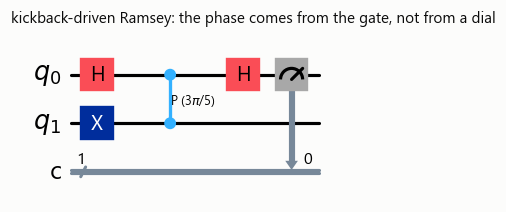

In [6]:
fig, ax = plt.subplots(figsize=(6.0, 1.95))
style.qiskit_grid(fig, left=0.015, right=0.985, top=0.80, bottom=0.02)
demo = QuantumCircuit(QuantumRegister(2, "q"), ClassicalRegister(1, "c"))
demo.x(1)
demo.h(0)
demo.cp(THETA, 0, 1)
demo.h(0)
demo.measure(0, 0)
demo.draw("mpl", ax=ax, style={"backgroundcolor": style.SURFACE})
ax.set_title("", loc="center")
ax.set_title("kickback-driven Ramsey: the phase comes from the gate, not from "
             "a dial", loc="left", fontsize=10)
plt.show()

## Figure 2 — before and after, four ways

**Left pair.** The two-qubit state as amplitude bars, labelled
$|q_1 q_0\rangle = |\text{target},\text{control}\rangle$. All four heights are
**identical** before and after — a computational-basis measurement of either
qubit is completely unchanged. Only the hue and the clock hand move, and only on
$|11\rangle$, the one basis state where both qubits read 1.

**Right pair.** The same event on the Bloch sphere, from each qubit's reduced
density matrix. `partial_trace(sv, qargs)` throws away the qubits in `qargs` —
note that it takes the ones to **discard**, not the ones to keep, which is a
one-character bug that returns a perfectly plausible wrong answer. The control
swings around the equator by exactly $\theta$. The target does not move at all.

That is the whole of phase kickback in one figure: a gate applied *to* the target
shows up *on* the control.

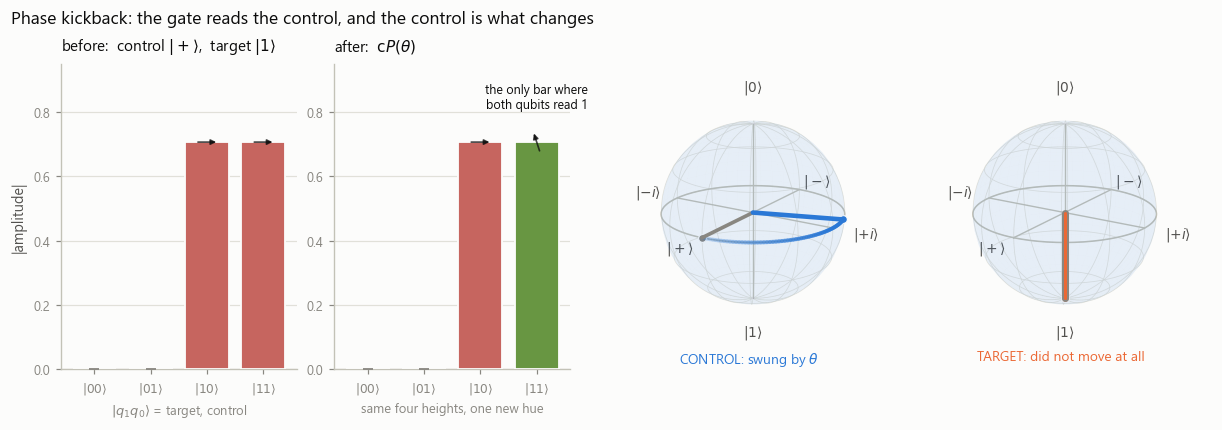

control Bloch  before: [1. 0. 0.]
control Bloch  after : [-0.309017  0.951057  0.      ]
target  Bloch  before: [ 0.  0. -1.]
target  Bloch  after : [ 0.  0. -1.]

target unmoved? True
control still pure? |r| = 1.000000000000
control rotated by   : 0.300000 x 2pi


In [7]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def bloch_vector(sv, qubit, n=2):
    """r = (<X>, <Y>, <Z>) of one qubit of a state, via partial_trace.

    partial_trace's second argument is the list of qubits to DISCARD.
    """
    rho = partial_trace(Statevector(sv), [q for q in range(n) if q != qubit])
    return np.array([np.trace(rho.data @ P).real for P in (X, Y, Z)])


rc0, rt0 = bloch_vector(before, 0), bloch_vector(before, 1)
rc1, rt1 = bloch_vector(after, 0), bloch_vector(after, 1)

fig = plt.figure(figsize=(11.0, 3.8))
gs = fig.add_gridspec(1, 4, width_ratios=[0.86, 0.86, 1.10, 1.10])

ax0 = fig.add_subplot(gs[0, 0])
grid.amp_bars(ax0, before, ylim=0.95)
ax0.set_title("before:  control " + grid.ket("+") + ",  target "
              + grid.ket("1"), loc="left", fontsize=10)
ax0.set_xlabel(r"$|q_1 q_0\rangle$ = target, control", fontsize=8.5,
               color=style.MUTED)

ax1 = fig.add_subplot(gs[0, 1])
grid.amp_bars(ax1, after, ylim=0.95)
ax1.set_ylabel("")
ax1.set_title(r"after:  $\mathrm{c}P(\theta)$", loc="left", fontsize=10)
ax1.set_xlabel("same four heights, one new hue", fontsize=8.5,
               color=style.MUTED)
# Directly over the bar rather than on a leader line: at four bars a leader has
# to cross one of them to reach the last.
ax1.annotate("the only bar where\nboth qubits read 1", xy=(3, 0.707),
             xytext=(0, 20), textcoords="offset points", ha="center",
             va="bottom", fontsize=8.2, color=style.INK, zorder=8)

# mplot3d leaves a wide margin around the sphere; zoom reclaims it.
arc = np.linspace(0, THETA, 60)
axb = fig.add_subplot(gs[0, 2], projection="3d")
bloch.sphere(axb, alpha=0.05)
bloch.path(axb, np.stack([np.cos(arc), np.sin(arc), np.zeros_like(arc)], axis=1),
           color=style.BLUE, lw=2.6)
bloch.vector(axb, rc0, color=style.MUTED, lw=2.4)
bloch.vector(axb, rc1, color=style.BLUE, lw=3.0)
axb.set_box_aspect((1, 1, 1), zoom=1.55)
bloch.label(axb, r"CONTROL: swung by $\theta$", y=0.06, color=style.BLUE)

axt = fig.add_subplot(gs[0, 3], projection="3d")
bloch.sphere(axt, alpha=0.05)
bloch.vector(axt, rt0, color=style.MUTED, lw=4.6)
# Both arrows land on the same point, so they share one caption.
bloch.vector(axt, rt1, color=style.ORANGE, lw=2.0)
axt.set_box_aspect((1, 1, 1), zoom=1.55)
bloch.label(axt, "TARGET: did not move at all", y=0.06, color=style.ORANGE)

fig.suptitle("Phase kickback: the gate reads the control, and the control is "
             "what changes", x=0.004, ha="left", fontsize=11.5)
plt.show()

print("control Bloch  before:", np.round(rc0, 6))
print("control Bloch  after :", np.round(rc1, 6))
print("target  Bloch  before:", np.round(rt0, 6))
print("target  Bloch  after :", np.round(rt1, 6))
print("\ntarget unmoved?", np.allclose(rt0, rt1, atol=1e-12))
print("control still pure? |r| =", f"{np.linalg.norm(rc1):.12f}")
print("control rotated by   :",
      f"{np.arctan2(rc1[1], rc1[0]) % (2*np.pi) / (2*np.pi):.6f} x 2pi")

---

## Part 3 — kickback as an instrument, and where it stops working

Chain the two halves together and you have a **measuring device for a gate's
eigenphase**: prepare the target in the eigenstate, put the control in
$|+\rangle$, apply the controlled gate, close with a Hadamard, and count. The
control reads 0 with probability $\cos^2(\theta/2)$, so

$$\hat\theta = 2\arccos\sqrt{\hat p_0}.$$

That is a one-bit, one-shot-at-a-time phase estimator — the primitive that B24's
quantum phase estimation stacks up into many bits at once.

**Left panel.** $\hat\theta$ from 4096 shots against the true $\theta$, with the
error bar propagated from the binomial $\sigma_{p_0}$ through the arccos:

$$\sigma_\theta = \frac{\sigma_{p_0}}{\sqrt{p_0(1-p_0)}}
= \frac{1}{\sqrt N}.$$

That cancellation is worth a second look, because it is not an accident and it is
not obvious. Near $\theta = 0$ the fringe is *flat* — $dp_0/d\theta \to 0$, so a
given amount of counting noise maps to a large uncertainty in $\theta$. But near
$\theta = 0$ the outcome is also nearly deterministic, so there is barely any
counting noise to map. The two effects cancel **exactly**, and the phase
uncertainty is $1/\sqrt N$ at every $\theta$. Every error bar in the left panel is
the same length. That is the **standard quantum limit** for phase estimation with
$N$ independent probes, and beating it is the entire business of quantum
metrology.

What does go wrong at the ends is *bias*, not variance: $\hat p_0$ cannot exceed
1, so $\hat\theta$ cannot go below 0, and an estimator pressed against a boundary
is pushed systematically away from it.

**Middle and right.** Now break it. Move the target off the eigenstate,
$|u_\alpha\rangle = \cos\alpha\,|0\rangle + \sin\alpha\,|1\rangle$, prepared with
`ry(2*alpha)`. The two branches of the control now get attached to two *different*
target states, the output is **entangled**, and the control is no longer pure. Its
equatorial length

$$|r_{xy}| = \big|\underbrace{\cos^2\!\alpha + e^{i\theta}\sin^2\!\alpha}_{\textstyle z}\big|$$

is exactly the **contrast** of the fringe you get by adding one more phase
$\varphi$ on the control before the closing Hadamard:

$$P(0) = \tfrac12\big(1 + \mathrm{Re}\,(e^{i\varphi} z)\big).$$

On the eigenstate ($\alpha = \pi/2$) that is $z = e^{i\theta}$ and the fringe is
full-contrast but **shifted by $\theta$** — the kickback is visible as a
displacement of the interferogram, which is exactly how a real experiment reads a
phase. Off the eigenstate the fringe stays where it is and *shrinks*. At
$\alpha = \pi/4$ the contrast drops to $|\cos(\theta/2)|$, and with $\theta = \pi$
it would hit **zero** — the control learns nothing, because the target has learned
everything.

That trade is not a defect of this circuit. It is the conservation law that runs
through the whole subject: **the more some other system knows which branch you
took, the less those branches can interfere.** The next section is the same
sentence again, with "some other system" being the environment.

In [8]:
def kickback_ramsey(theta, phi=0.0, alpha=np.pi / 2):
    """Ramsey on the control, with the phase supplied by kickback.

    alpha = pi/2 puts the target in |1>, an exact eigenstate of P(theta).
    Any other alpha mixes in |0>, whose eigenvalue is 1, and the two branches
    stop being the same state.

    ``phi`` is an extra, KNOWN phase on the control, applied after the
    controlled gate. Sweeping it traces out the interferogram whose shift is the
    kicked phase and whose contrast is |r_xy| of the control.
    """
    qr, cr = QuantumRegister(2, "q"), ClassicalRegister(1, "c")
    qc = QuantumCircuit(qr, cr)
    qc.ry(2 * alpha, 1)          # target: cos(alpha)|0> + sin(alpha)|1>
    qc.h(0)
    qc.cp(theta, 0, 1)
    qc.p(phi, 0)                 # the dial we turn
    qc.h(0)
    qc.measure(0, 0)             # read the CONTROL only
    return qc


def kickback_state_alpha(theta, alpha):
    """The same thing without the final H or the measurement."""
    qc = QuantumCircuit(2)
    qc.ry(2 * alpha, 1)
    qc.h(0)
    qc.cp(theta, 0, 1)
    return qc


# ---- the estimator: theta recovered from counts
THETA_TRUE = np.linspace(0.12, 2 * np.pi - 0.12, 15)
sampler = backends.sampler(shots=SHOTS, seed=SEED + 11)
res = sampler.run([kickback_ramsey(t) for t in THETA_TRUE]).result()
p0_kb = np.array([res[k].data.c.get_counts().get("0", 0) / SHOTS
                  for k in range(len(THETA_TRUE))])
sig_p0 = np.sqrt(p0_kb * (1 - p0_kb) / SHOTS)

theta_hat = 2 * np.arccos(np.sqrt(np.clip(p0_kb, 0.0, 1.0)))
# d(theta)/d(p0) = -1 / sqrt(p0 (1-p0)); the arccos is monotone so |.| is fine.
with np.errstate(divide="ignore", invalid="ignore"):
    sig_theta = sig_p0 / np.sqrt(np.clip(p0_kb * (1 - p0_kb), 1e-12, None))

# theta > pi folds back: cos^2 is symmetric about pi, so a single fringe point
# cannot tell theta from 2pi - theta. Unfold it by hand and say so.
theta_hat_unfolded = np.where(THETA_TRUE > np.pi,
                              2 * np.pi - theta_hat, theta_hat)

print(f"{'theta/2pi':>10} {'p0':>8} {'theta_hat/2pi':>15} {'sigma/2pi':>11}")
for t, p, th, sg in zip(THETA_TRUE, p0_kb, theta_hat_unfolded, sig_theta):
    print(f"{t/(2*np.pi):10.4f} {p:8.4f} {th/(2*np.pi):15.4f} "
          f"{sg/(2*np.pi):11.4f}")

# ---- off the eigenstate: contrast from the control's reduced state
ALPHAS = np.linspace(0, np.pi / 2, 121)
contrast_exact = np.array([
    np.linalg.norm(bloch_vector(Statevector(kickback_state_alpha(THETA, a)).data,
                                0)[:2])
    for a in ALPHAS])
contrast_analytic = np.abs(np.cos(ALPHAS) ** 2
                           + np.exp(1j * THETA) * np.sin(ALPHAS) ** 2)
print("\nreduced-state contrast == |cos^2 a + e^{i theta} sin^2 a| ?",
      np.allclose(contrast_exact, contrast_analytic, atol=1e-12))

# ---- and the same thing measured: sweep the extra phase phi at three alphas
ALPHA_SHOW = [np.pi / 2, np.pi / 3, np.pi / 4]
PHI_SWEEP = np.linspace(0, 2 * np.pi, 25)


def measure_fringe(alpha, seed):
    """P(control reads 0) across the phi sweep, at fixed theta = THETA."""
    s = backends.sampler(shots=SHOTS, seed=seed)
    r = s.run([kickback_ramsey(THETA, phi=f, alpha=alpha)
               for f in PHI_SWEEP]).result()
    p = np.array([r[j].data.c.get_counts().get("0", 0) / SHOTS
                  for j in range(len(PHI_SWEEP))])
    return p, np.sqrt(p * (1 - p) / SHOTS)


fringes = {a: measure_fringe(a, SEED + 40 + k)
           for k, a in enumerate(ALPHA_SHOW)}

# sampled contrast at a grid of alphas, for the middle panel's dots.
# A 25-point sweep resolves the extremes to well under a percent of contrast.
ALPHA_PTS = np.linspace(0, np.pi / 2, 9)
contrast_pts = np.array([np.ptp(measure_fringe(a, SEED + 70 + k)[0])
                         for k, a in enumerate(ALPHA_PTS)])
print("\nsampled contrast at alpha = pi/4 :", f"{contrast_pts[4]:.4f}")
print("expected |cos(theta/2)|          :", f"{abs(np.cos(THETA / 2)):.4f}")

 theta/2pi       p0   theta_hat/2pi   sigma/2pi
    0.0191   0.9973          0.0165      0.0025
    0.0878   0.9287          0.0860      0.0025
    0.1565   0.7742          0.1576      0.0025
    0.2252   0.5723          0.2269      0.0025
    0.2939   0.3757          0.2900      0.0025
    0.3626   0.1746          0.3628      0.0025
    0.4313   0.0378          0.4377      0.0025
    0.5000   0.0000          0.5000      0.0000
    0.5687   0.0515          0.5729      0.0025
    0.6374   0.1777          0.6385      0.0025
    0.7061   0.3840          0.7127      0.0025
    0.7748   0.5776          0.7748      0.0025
    0.8435   0.7803          0.8447      0.0025
    0.9122   0.9248          0.9116      0.0025
    0.9809   0.9958          0.9795      0.0025

reduced-state contrast == |cos^2 a + e^{i theta} sin^2 a| ? True



sampled contrast at alpha = pi/4 : 0.5920
expected |cos(theta/2)|          : 0.5878


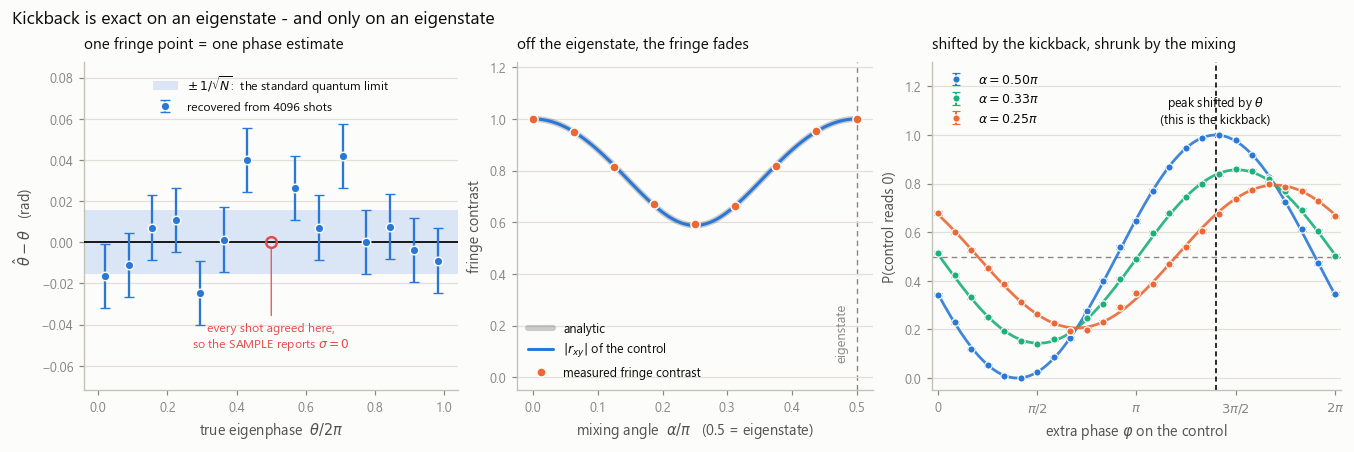

contrast at alpha = pi/4 (exact) : 0.587785
expected |cos(theta/2)|          : 0.587785

every phase error bar is 1/sqrt(N):
  measured sigma_theta range: [0.015625, 0.015625] rad
  1/sqrt(N)                 : 0.015625 rad
  excluded: theta/pi = [1.], where every shot agreed
            -> sigma ESTIMATED FROM THE SAMPLE is 0. Honest, but not the truth.
worst |recovered - true|    : 0.0418 rad
  residuals in units of sigma: [-1.04 -0.71  0.45  0.69 -1.58  0.08  2.57  1.68  0.45  2.67  0.    0.48
 -0.25 -0.57]
  mean z^2 = 1.58 over 14 points -> consistent with 1, i.e. the bars are the right size


In [9]:
fig = plt.figure(figsize=(12.2, 4.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.0, 1.15])

# ---- (a) the RESIDUAL, not a parity plot: at 4096 shots the error bars are
# sub-pixel against a full 2*pi axis, so a y = x plot would assert a claim about
# them that it cannot show. Subtracting the truth puts the bars on their own
# scale, where the whole point - that they are all the same length - is visible.
axa = fig.add_subplot(gs[0, 0])
SQL = 1 / np.sqrt(SHOTS)
resid_theta = theta_hat_unfolded - THETA_TRUE
sat = ~((p0_kb > 0) & (p0_kb < 1))

axa.axhspan(-SQL, SQL, color=style.BLUE, alpha=0.16, lw=0, zorder=1,
            label=r"$\pm\,1/\sqrt{N}$:  the standard quantum limit")
axa.axhline(0.0, color=style.INK, lw=1.2, zorder=3)
axa.errorbar(THETA_TRUE[~sat] / (2 * np.pi), resid_theta[~sat],
             yerr=sig_theta[~sat], ls="none", marker="o", ms=5.6,
             color=style.BLUE, markeredgecolor=style.SURFACE,
             markeredgewidth=0.9, elinewidth=1.5, capsize=3.0, zorder=5,
             label=f"recovered from {SHOTS} shots")
if sat.any():
    axa.plot(THETA_TRUE[sat] / (2 * np.pi), resid_theta[sat], ls="none",
             marker="o", ms=7.0, mfc="none", mec=style.RED, mew=1.6, zorder=6)
    axa.annotate("every shot agreed here,\nso the SAMPLE reports $\\sigma = 0$",
                 xy=(THETA_TRUE[sat][0] / (2 * np.pi), resid_theta[sat][0]),
                 xytext=(0, -52), textcoords="offset points", ha="center",
                 va="top", fontsize=8.0, color=style.RED, zorder=7,
                 arrowprops=dict(arrowstyle="-", color=style.RED, lw=0.8,
                                 shrinkA=2, shrinkB=4))
axa.set_xlim(-0.04, 1.04)
axa.set_ylim(-4.6 * SQL, 5.6 * SQL)
axa.set_xlabel(r"true eigenphase  $\theta / 2\pi$")
axa.set_ylabel(r"$\hat\theta - \theta$   (rad)")
axa.legend(loc="upper center", fontsize=8.0, ncols=1)
axa.set_title("one fringe point = one phase estimate", loc="left", fontsize=10)

# ---- (b) contrast vs alpha
axb = fig.add_subplot(gs[0, 1])
axb.plot(ALPHAS / np.pi, contrast_analytic, color=style.INK, lw=4.0, alpha=0.20,
         zorder=2, label="analytic")
axb.plot(ALPHAS / np.pi, contrast_exact, color=style.BLUE, lw=2.0, zorder=3,
         label=r"$|r_{xy}|$ of the control")
axb.plot(ALPHA_PTS / np.pi, contrast_pts, ls="none", marker="o", ms=6.0,
         color=style.ORANGE, markeredgecolor=style.SURFACE, markeredgewidth=1.0,
         zorder=5, label="measured fringe contrast")
axb.axvline(0.5, color=style.MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)
axb.text(0.487, 0.06, "eigenstate", fontsize=8.5, color=style.MUTED,
         rotation=90, va="bottom", ha="right")
axb.set_xlabel(r"mixing angle  $\alpha/\pi$   (0.5 = eigenstate)")
axb.set_ylabel("fringe contrast")
axb.set_ylim(-0.05, 1.22)
axb.legend(loc="lower left", fontsize=8.2)
axb.set_title("off the eigenstate, the fringe fades", loc="left", fontsize=10)

# ---- (c) the fringes themselves
axc = fig.add_subplot(gs[0, 2])
phi_fine = np.linspace(0, 2 * np.pi, 241)
for (a, col) in zip(ALPHA_SHOW, [style.BLUE, style.AQUA, style.ORANGE]):
    p, sg = fringes[a]
    # P(0) = (1 + Re(e^{i phi} z))/2, with z = cos^2 a + e^{i theta} sin^2 a.
    z = np.cos(a) ** 2 + np.exp(1j * THETA) * np.sin(a) ** 2
    axc.plot(phi_fine, 0.5 * (1 + (np.exp(1j * phi_fine) * z).real),
             color=col, lw=1.8, alpha=0.9, zorder=3)
    axc.errorbar(PHI_SWEEP, p, yerr=sg, ls="none", marker="o", ms=4.8,
                 color=col, markeredgecolor=style.SURFACE, markeredgewidth=0.8,
                 elinewidth=1.3, capsize=2.4, zorder=5,
                 label=rf"$\alpha = {a/np.pi:.2f}\pi$")
axc.axhline(0.5, color=style.MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)
# the peak of the alpha = pi/2 fringe sits at 2pi - theta: that shift IS the
# kicked phase, and it is how a real experiment reads one off.
axc.axvline(2 * np.pi - THETA, color=style.INK, lw=1.1, ls=(0, (3, 2)),
            zorder=2)
axc.annotate(r"peak shifted by $\theta$" + "\n(this is the kickback)",
             xy=(2 * np.pi - THETA, 1.0), xytext=(0, 6),
             textcoords="offset points", ha="center", va="bottom",
             fontsize=8.2, color=style.INK)
axc.set_xlim(-0.1, 2 * np.pi + 0.1)
axc.set_ylim(-0.05, 1.30)
axc.set_xticks(np.linspace(0, 2 * np.pi, 5))
axc.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axc.set_xlabel(r"extra phase $\varphi$ on the control")
axc.set_ylabel("P(control reads 0)")
axc.legend(loc="upper left", ncols=1, fontsize=8.2)
axc.set_title("shifted by the kickback, shrunk by the mixing", loc="left",
              fontsize=10)

fig.suptitle("Kickback is exact on an eigenstate - and only on an eigenstate",
             x=0.004, ha="left", fontsize=11.5)
plt.show()

print("contrast at alpha = pi/4 (exact) :",
      f"{np.linalg.norm(bloch_vector(Statevector(kickback_state_alpha(THETA, np.pi/4)).data, 0)[:2]):.6f}")
print("expected |cos(theta/2)|          :",
      f"{abs(np.cos(THETA / 2)):.6f}")
ok = (p0_kb > 0) & (p0_kb < 1)
print("\nevery phase error bar is 1/sqrt(N):")
print("  measured sigma_theta range:",
      f"[{sig_theta[ok].min():.6f}, {sig_theta[ok].max():.6f}] rad")
print("  1/sqrt(N)                 :", f"{1/np.sqrt(SHOTS):.6f} rad")
if not ok.all():
    bad = THETA_TRUE[~ok] / np.pi
    print(f"  excluded: theta/pi = {np.round(bad, 3)}, where every shot agreed")
    print("            -> sigma ESTIMATED FROM THE SAMPLE is 0. Honest, but "
          "not the truth.")
print("worst |recovered - true|    :",
      f"{np.max(np.abs(theta_hat_unfolded - THETA_TRUE)):.4f} rad")
zr = (theta_hat_unfolded[ok] - THETA_TRUE[ok]) / sig_theta[ok]
print("  residuals in units of sigma:", np.round(zr, 2))
print(f"  mean z^2 = {np.mean(zr**2):.2f} over {ok.sum()} points "
      f"-> consistent with 1, i.e. the bars are the right size")

---

## Part 4 — eight paths instead of two

A08's Figure 3 asked what happens with **eight** routes instead of two. Here it
is as a circuit.

Take three qubits, `h` them all (so all eight basis states carry amplitude
$1/\sqrt8$), then apply a **phase ramp**: basis state $|k\rangle$ picks up
$e^{ik\varphi}$. Since $k = 4b_2 + 2b_1 + b_0$, that is three ordinary phase
gates — `p(phi, 0)`, `p(2*phi, 1)`, `p(4*phi, 2)` — and nothing else. Then `h`
them all again.

Every output amplitude is now a sum of **eight** arrows,

$$a_j = \frac{1}{8}\sum_{k=0}^{7} e^{ik\varphi}\,(-1)^{\,k \cdot j},$$

and for the $|000\rangle$ output the sign factor is always $+1$, so the sum is a
geometric series and collapses to the **N-slit diffraction** formula

$$P(000) = \left(\frac{\sin 4\varphi}{8\sin(\varphi/2)}\right)^{2}.$$

If the doubling ramp $\varphi, 2\varphi, 4\varphi$ looks familiar, it should: it
is the same structure as the controlled powers $U^{2^k}$ in phase estimation, and
the final `h` layer is a one-frequency stand-in for the inverse QFT. B24 replaces
that layer with `QFTGate` and reads $\varphi$ off the register directly.

In [10]:
N_Q = 3
DIM = 2 ** N_Q


def multipath(phi, n=N_Q):
    """H^(x)n -> phase ramp exp(i k phi) -> H^(x)n."""
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for q in range(n):
        qc.p(phi * 2 ** q, q)
    qc.h(range(n))
    return qc


# The ramp really is exp(i k phi) on the diagonal - three p gates, no hand-waving.
ramp = QuantumCircuit(N_Q)
for q in range(N_Q):
    ramp.p(0.37 * 2 ** q, q)
assert np.allclose(np.diag(Operator(ramp).data),
                   np.exp(1j * 0.37 * np.arange(DIM)))
print("the three p gates ARE the diagonal exp(i k phi):", True)

PHIS = np.linspace(0, 2 * np.pi, 181)
water = np.array([Statevector(multipath(p)).probabilities() for p in PHIS])

with np.errstate(divide="ignore", invalid="ignore"):
    analytic = np.where(np.abs(np.sin(PHIS / 2)) < 1e-9, 1.0,
                        (np.sin(4 * PHIS) / (8 * np.sin(PHIS / 2))) ** 2)
print("max |P(000) - N-slit formula|:",
      f"{np.max(np.abs(water[:, 0] - analytic)):.2e}")
print("every row is a distribution:", np.allclose(water.sum(axis=1), 1.0))

# The null at phi = pi/4: eight arrows closing into a complete circle.
null = Statevector(multipath(np.pi / 4)).data
print(f"\nP(000) at phi = pi/4: {abs(null[0])**2:.3e}  (an exact zero)")

the three p gates ARE the diagonal exp(i k phi): True


max |P(000) - N-slit formula|: 1.33e-15
every row is a distribution: True

P(000) at phi = pi/4: 1.087e-33  (an exact zero)


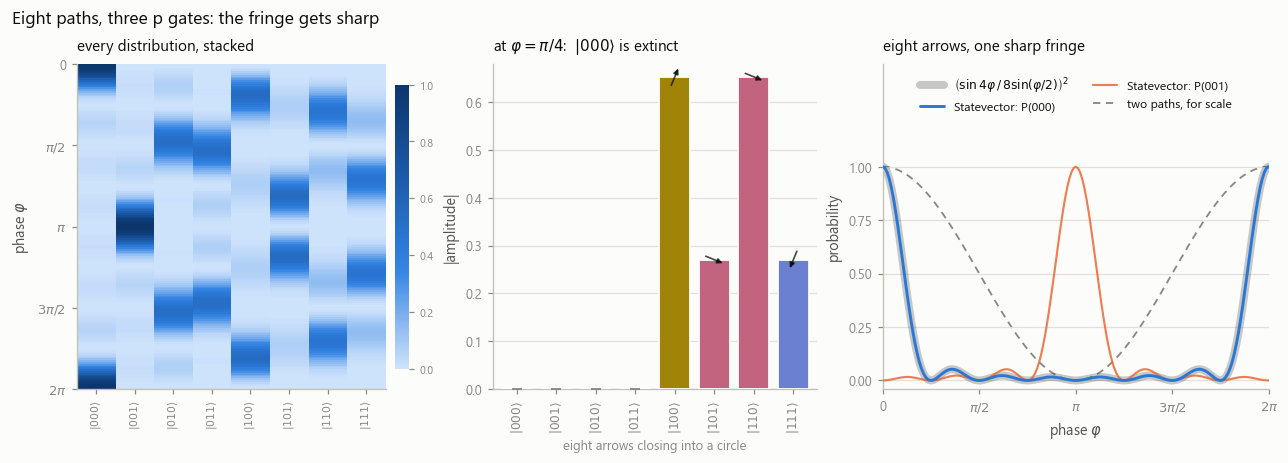

two-path peak is 180 deg wide at half height
eight-path peak is 40 deg wide at half height


In [11]:
fig = plt.figure(figsize=(11.6, 4.1))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.05, 1.25])

# ---- (a) every distribution, stacked
axh = fig.add_subplot(gs[0, 0])
im = axh.imshow(water, aspect="auto", origin="upper", cmap=style.SEQ,
                vmin=0, vmax=water.max(),
                extent=(-0.5, DIM - 0.5, 2 * np.pi, 0.0),
                interpolation="nearest")
axh.set_xticks(range(DIM))
axh.set_xticklabels([grid.ket(format(i, f"0{N_Q}b")) for i in range(DIM)],
                    rotation=90, fontsize=7)
axh.set_yticks(np.linspace(0, 2 * np.pi, 5))
axh.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axh.set_ylabel(r"phase $\varphi$")
axh.grid(False)
cb = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
axh.set_title("every distribution, stacked", loc="left", fontsize=10)

# ---- (b) the state at the diffraction null
axn = fig.add_subplot(gs[0, 1])
grid.amp_bars(axn, null, ylim=0.68, label_rotation=90)
axn.set_title(r"at $\varphi = \pi/4$:  $|000\rangle$ is extinct", loc="left",
              fontsize=10)
axn.set_xlabel("eight arrows closing into a circle", fontsize=8.5,
               color=style.MUTED)

# ---- (c) the |000> cut against the analytic fringe
axc = fig.add_subplot(gs[0, 2])
axc.plot(PHIS, analytic, color=style.INK, lw=5.2, alpha=0.22, zorder=2,
         label=r"$\left(\sin 4\varphi\,/\,8\sin(\varphi/2)\right)^2$")
axc.plot(PHIS, water[:, 0], color=style.BLUE, lw=1.9, zorder=4,
         label="Statevector: P(000)")
axc.plot(PHIS, water[:, 1], color=style.ORANGE, lw=1.4, alpha=0.85, zorder=3,
         label="Statevector: P(001)")
axc.plot(PHI_DENSE, np.cos(PHI_DENSE / 2) ** 2, color=style.MUTED, lw=1.2,
         ls=(0, (4, 3)), zorder=1, label=r"two paths, for scale")
axc.set_xlim(0, 2 * np.pi)
axc.set_ylim(-0.04, 1.48)
axc.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axc.set_xticks(np.linspace(0, 2 * np.pi, 5))
axc.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axc.set_xlabel(r"phase $\varphi$")
axc.set_ylabel("probability")
axc.legend(loc="upper center", ncols=2, fontsize=8.0)
axc.set_title("eight arrows, one sharp fringe", loc="left", fontsize=10)

fig.suptitle("Eight paths, three p gates: the fringe gets sharp",
             x=0.004, ha="left", fontsize=11.5)
plt.show()

peak_two = 1.0
half_width_two = np.pi                      # cos^2 is half a period wide
above_half = PHIS[(water[:, 0] > 0.5) & (PHIS < np.pi)]
print(f"two-path peak is {np.degrees(half_width_two):.0f} deg wide at "
      f"half height")
print(f"eight-path peak is {2*np.degrees(above_half.max()):.0f} deg wide at "
      f"half height")

Three things the waterfall shows that the two-path fringe could not.

**Sharpness.** With two paths the peak is a lazy $\cos^2$, half a period wide.
With eight it is a spike: away from $\varphi = 0$ the arrows spread around the
circle and cancel almost perfectly. More paths means *sharper* discrimination —
the same reason a diffraction grating out-resolves a double slit, and the same
reason phase estimation gets more precise with more qubits.

**Redistribution, not destruction.** Every row of the heatmap sums to exactly 1.
Interference never destroys probability; it moves it. When $|000\rangle$ goes
dark, look along the row to see where the mass went.

**Structure is basis-dependent.** The columns have different fringe patterns
because the sign factor $(-1)^{k\cdot j}$ differs per output. Reading which column
lights up at which $\varphi$ is, essentially, phase estimation.

---

## Part 5 — and now we kill it

Everything so far assumed $\varphi$ was a number we control exactly. Real hardware
does not offer that. Stray fields, thermal fluctuations and coupling to anything
at all mean the phase actually applied is $\varphi + \delta$, with $\delta$ a
random kick that differs shot to shot. This is **dephasing**, and it is the
dominant enemy of interference.

A08 modelled it as an ensemble average over Gaussian kicks and got

$$\overline{P(0)} = \tfrac12\left(1 + e^{-\sigma^2/2}\cos\varphi\right),$$

using $\overline{e^{i\delta}} = e^{-\sigma^2/2}$. The fringe keeps its shape and
its **centre**; what it loses is **contrast**.

### Being honest about which model this is

There are two genuinely different things people mean by "dephasing", and A08's
version is the weaker one. We do **both** here, and show they coincide.

**(i) The jitter ensemble.** Insert an extra `rz(delta)` with $\delta$ drawn from
$\mathcal{N}(0,\sigma^2)$, run, and average the *probabilities* over the ensemble
— not the amplitudes, because each shot is a separate experiment and it is the
counts that pile up. This is classical randomness we happen not to know. We
evaluate the average with 32-node Gauss–Hermite quadrature, so it is smooth and
exactly reproducible.

**(ii) The channel.** Aer's `phase_damping_error(lam)` — a genuine CPTP map whose
Kraus operators are $K_0 = \mathrm{diag}(1, \sqrt{1-\lambda})$ and
$K_1 = \mathrm{diag}(0, \sqrt{\lambda})$. It multiplies the off-diagonal elements
of $\rho$ — literally the terms that carry interference — by $\sqrt{1-\lambda}$.

These are the same map when $\sqrt{1-\lambda} = e^{-\sigma^2/2}$, i.e.

$$\lambda = 1 - e^{-\sigma^{2}}.$$

Which is the honest punchline: **an ensemble of unknown phases is
indistinguishable from a decoherence channel.** Not "similar to" — the density
matrices are equal, entry for entry, and no experiment can separate them. That
equivalence is what makes A08's toy model legitimate, and it is checked below at
$10^{-12}$.

**(iii) And then real shots**, through `SamplerV2` with that noise model attached,
so the dots carry binomial error bars rather than a fabricated uncertainty.

The three panels: the fringe family flattening, a map of $P(0)$ over
$(\varphi, \sigma)$, and the contrast falling onto $e^{-\sigma^2/2}$.

In [12]:
# ---- (i) the jitter ensemble, by Gauss-Hermite quadrature.
# integral of exp(-x^2) f(x) dx = sum w_i f(x_i); with delta = sqrt(2) sigma x
# this averages f over N(0, sigma^2) exactly.
GH_X, GH_W = np.polynomial.hermite.hermgauss(32)
GH_W = GH_W / np.sqrt(np.pi)


def jitter_p0(phi, sigma):
    """Ensemble-averaged P(0) with an extra rz(delta) of width sigma."""
    if sigma == 0.0:
        return float(Statevector(ramsey(phi)).probabilities()[0])
    deltas = np.sqrt(2.0) * sigma * GH_X
    ps = np.array([Statevector(ramsey(phi + d)).probabilities()[0]
                   for d in deltas])
    return float(GH_W @ ps)


# ---- (ii) the channel.
def lam_of(sigma):
    """The phase-damping strength equivalent to Gaussian jitter of width sigma."""
    return 1.0 - np.exp(-sigma ** 2)


def dephasing_model(sigma):
    """phase_damping_error attached to the p gate - the "delay" in the circuit."""
    nm = NoiseModel()
    lam = lam_of(sigma)
    if lam > 0:
        nm.add_all_qubit_quantum_error(phase_damping_error(lam), ["p"])
    return nm


# The Kraus operators, so nothing here is taken on faith.
K = Kraus(phase_damping_error(0.4)).data
print("phase_damping_error(0.4) Kraus operators:")
for k_ in K:
    print(np.round(np.asarray(k_), 6).tolist())
print("K0 == diag(1, sqrt(1-lam)) ?",
      np.allclose(np.asarray(K[0]), np.diag([1.0, np.sqrt(0.6)])))


def channel_fringe(phis, sigma):
    """P(0) across a phi grid, from Aer's density-matrix simulator.

    One batched run per sigma. save_density_matrix is registered on
    QuantumCircuit by importing qiskit_aer.
    """
    circs = []
    for phi in phis:
        qc = ramsey(phi)
        qc.save_density_matrix(label="rho")
        circs.append(qc)
    sim = backends.get_backend(noise_model=dephasing_model(sigma),
                               method="density_matrix", seed_simulator=SEED)
    res = sim.run(circs).result()
    return np.array([np.real(np.asarray(res.data(k)["rho"])[0, 0])
                     for k in range(len(phis))])


SIG_GRID = np.linspace(0.0, 2.4, 31)
PHI_GRID = np.linspace(0, 2 * np.pi, 61)
sheet = np.array([channel_fringe(PHI_GRID, s) for s in SIG_GRID])

# (i) == (ii), to machine precision, on a spot grid.
worst = 0.0
for s in (0.0, 0.35, 0.8, 1.5, 2.4):
    k = int(np.argmin(np.abs(SIG_GRID - s)))
    q = np.array([jitter_p0(p, SIG_GRID[k]) for p in PHI_GRID])
    worst = max(worst, float(np.max(np.abs(q - sheet[k]))))
print(f"\njitter ensemble vs phase-damping channel: max |difference| = "
      f"{worst:.3e}")

contrast_sheet = sheet.max(axis=1) - sheet.min(axis=1)
print("contrast(sigma) == exp(-sigma^2/2) ?",
      np.allclose(contrast_sheet, np.exp(-SIG_GRID ** 2 / 2), atol=1e-9))


def channel_contrast(sigma):
    """Contrast straight from the channel at THIS sigma - two circuits.

    Reading it off the plotted sheet instead would snap sigma to the nearest
    grid point and manufacture a disagreement of a few percent that is not
    there.
    """
    ends = channel_fringe(np.array([0.0, np.pi]), sigma)
    return float(ends[0] - ends[1])

phase_damping_error(0.4) Kraus operators:
[[(-0.335711+0j), 0j], [0j, (0.335711+0j)]]
[[(0.941965+0j), 0j], [0j, (0.941965+0j)]]
K0 == diag(1, sqrt(1-lam)) ? False



jitter ensemble vs phase-damping channel: max |difference| = 1.887e-15
contrast(sigma) == exp(-sigma^2/2) ? True


In [13]:
# ---- (iii) real shots through the noisy sampler.
SIG_PTS = np.array([0.0, 0.25, 0.5, 0.75, 1.0, 1.3, 1.7, 2.1])
PHI_MEAS = np.linspace(0, 2 * np.pi, 13)
c_meas, c_err = [], []
for k, s in enumerate(SIG_PTS):
    p0_s, sg_s = sampled_fringe(PHI_MEAS, seed=SEED + 200 + k,
                                noise_model=dephasing_model(s))
    hi, lo = int(np.argmax(p0_s)), int(np.argmin(p0_s))
    c_meas.append(p0_s[hi] - p0_s[lo])
    c_err.append(np.sqrt(sg_s[hi] ** 2 + sg_s[lo] ** 2))
c_meas, c_err = np.array(c_meas), np.array(c_err)

# ---- and the explicit rz-jitter route, sampled with the notebook's own rng,
#      so at least one number in this section is drawn rather than derived.
def jitter_sampled_contrast(sigma, draws=48, shots=1024, seed=SEED):
    """Draw phase kicks, run each as its own circuit, pool the counts."""
    r = np.random.default_rng(seed)
    d = r.normal(0.0, sigma, size=draws)
    s = backends.sampler(shots=shots, seed=seed)
    out = []
    for phi in (0.0, np.pi):
        res = s.run([ramsey_measured(phi + dd) for dd in d]).result()
        n0 = sum(res[j].data.c.get_counts().get("0", 0) for j in range(draws))
        out.append(n0 / (draws * shots))
    return out[0] - out[1]


# Same sigmas as the noise-model points, so every row of the table is filled
# and the two sampling routes are directly comparable.
jit_sigmas = SIG_PTS
jit_contrast = np.array([jitter_sampled_contrast(s, seed=SEED + 300 + k)
                         for k, s in enumerate(jit_sigmas)])
chan_contrast = np.array([channel_contrast(s) for s in SIG_PTS])

print(f"{'sigma':>6} {'exp(-s^2/2)':>13} {'channel':>10} {'shots':>10} "
      f"{'rz-jitter':>11}")
for k, s in enumerate(SIG_PTS):
    print(f"{s:6.2f} {np.exp(-s**2/2):13.6f} {chan_contrast[k]:10.6f} "
          f"{c_meas[k]:10.4f} {jit_contrast[k]:11.4f}")
print("\nthe channel column is exact, not fitted: max |channel - envelope| =",
      f"{np.max(np.abs(chan_contrast - np.exp(-SIG_PTS**2/2))):.2e}")

 sigma   exp(-s^2/2)    channel      shots   rz-jitter
  0.00      1.000000   1.000000     1.0000      1.0000
  0.25      0.969233   0.969233     0.9697      0.9713
  0.50      0.882497   0.882497     0.8782      0.8964
  0.75      0.754840   0.754840     0.7495      0.7232
  1.00      0.606531   0.606531     0.6025      0.5918
  1.30      0.429557   0.429557     0.4253      0.4280
  1.70      0.235746   0.235746     0.2319      0.2461
  2.10      0.110251   0.110251     0.1279      0.0669

the channel column is exact, not fitted: max |channel - envelope| = 9.99e-16


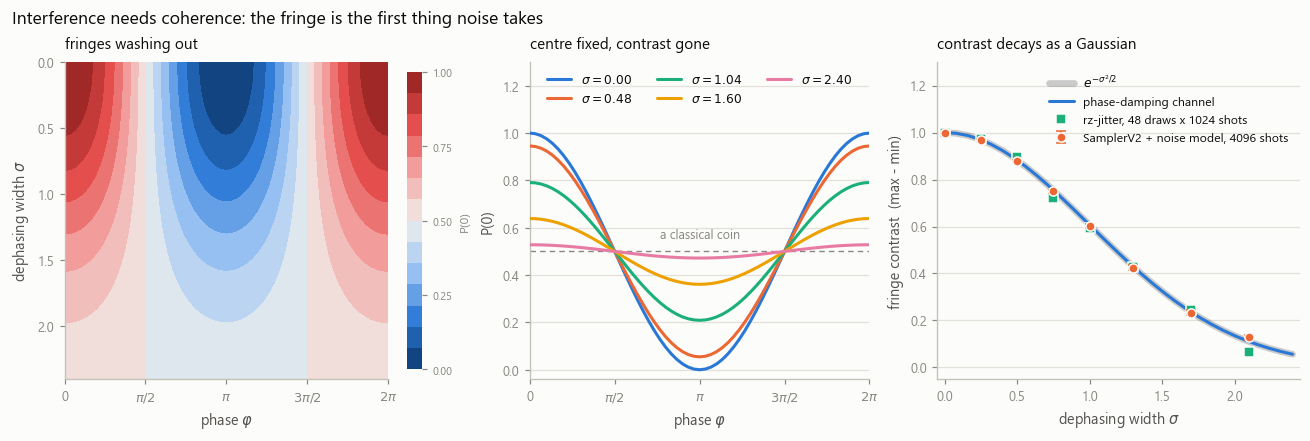

centre of the fringe never moves - P(0) at phi = pi/2, per sigma:
  sigma = 0.00:  P(0) = 0.500000000
  sigma = 0.80:  P(0) = 0.500000000
  sigma = 1.60:  P(0) = 0.500000000
  sigma = 2.40:  P(0) = 0.500000000


In [14]:
fig = plt.figure(figsize=(11.8, 3.9))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.05, 1.12])

# ---- (a) the map
axh = fig.add_subplot(gs[0, 0])
# Banded contours rather than a continuous image: the iso-contrast bands read
# better than a smooth wash, and a banded PNG is a fraction of the bytes.
im = axh.contourf(PHI_GRID, SIG_GRID, sheet, levels=np.linspace(0, 1, 15),
                  cmap=style.DIV, vmin=0.0, vmax=1.0)
axh.invert_yaxis()
axh.set_xticks(np.linspace(0, 2 * np.pi, 5))
axh.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axh.set_xlabel(r"phase $\varphi$")
axh.set_ylabel(r"dephasing width $\sigma$")
axh.grid(False)
cb = fig.colorbar(im, ax=axh, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
cb.set_label("P(0)", fontsize=8, color=style.MUTED)
axh.set_title("fringes washing out", loc="left", fontsize=10)

# ---- (b) the fringe family, with measured points on the extremes
axf = fig.add_subplot(gs[0, 1])
show = [0.0, 0.48, 1.04, 1.6, 2.4]
for s, col in zip(show, style.CAT):
    k = int(np.argmin(np.abs(SIG_GRID - s)))
    axf.plot(PHI_GRID, sheet[k], color=col, lw=2.0, zorder=3,
             label=rf"$\sigma = {SIG_GRID[k]:.2f}$")
axf.axhline(0.5, color=style.MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)
axf.text(2 * np.pi * 0.5, 0.545, "a classical coin", fontsize=8.2,
         color=style.MUTED, ha="center", va="bottom")
axf.set_xlim(0, 2 * np.pi)
axf.set_ylim(-0.04, 1.30)
axf.set_xticks(np.linspace(0, 2 * np.pi, 5))
axf.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axf.set_xlabel(r"phase $\varphi$")
axf.set_ylabel("P(0)")
axf.legend(loc="upper center", ncols=3, fontsize=8.0)
axf.set_title("centre fixed, contrast gone", loc="left", fontsize=10)

# ---- (c) contrast against the envelope
axc = fig.add_subplot(gs[0, 2])
axc.plot(SIG_GRID, np.exp(-SIG_GRID ** 2 / 2), color=style.INK, lw=4.4,
         alpha=0.20, zorder=2, label=r"$e^{-\sigma^2/2}$")
axc.plot(SIG_GRID, contrast_sheet, color=style.BLUE, lw=2.0, zorder=4,
         label="phase-damping channel")
axc.plot(jit_sigmas, jit_contrast, ls="none", marker="s", ms=6.0,
         color=style.AQUA, markeredgecolor=style.SURFACE, markeredgewidth=1.0,
         zorder=5, label="rz-jitter, 48 draws x 1024 shots")
axc.errorbar(SIG_PTS, c_meas, yerr=c_err, ls="none", marker="o", ms=6.0,
             color=style.ORANGE, markeredgecolor=style.SURFACE,
             markeredgewidth=1.0, elinewidth=1.6, capsize=3.2, zorder=6,
             label=f"SamplerV2 + noise model, {SHOTS} shots")
axc.set_xlim(-0.05, 2.45)
axc.set_ylim(-0.05, 1.30)
axc.set_xlabel(r"dephasing width $\sigma$")
axc.set_ylabel("fringe contrast  (max - min)")
axc.legend(loc="upper right", fontsize=8.0)
axc.set_title("contrast decays as a Gaussian", loc="left", fontsize=10)

fig.suptitle("Interference needs coherence: the fringe is the first thing "
             "noise takes", x=0.004, ha="left", fontsize=11.5)
plt.show()

print("centre of the fringe never moves - P(0) at phi = pi/2, per sigma:")
for s in (0.0, 0.8, 1.6, 2.4):
    k = int(np.argmin(np.abs(SIG_GRID - s)))
    j = int(np.argmin(np.abs(PHI_GRID - np.pi / 2)))
    print(f"  sigma = {SIG_GRID[k]:.2f}:  P(0) = {sheet[k, j]:.9f}")

The middle panel is the sentence to keep: **contrast, not centre.** Dephasing
does not bias the answer, it erases the signal. A fringe that has flattened onto
0.5 has not moved its peak somewhere misleading — it has stopped having a peak.
That is why $T_2$ is quoted as a *time you have*, not as an error you correct for:
past it there is nothing left to correct.

Two things about the right-hand panel are worth not glossing over.

The blue curve is **not a fit**. It is the channel's own contrast, and it lands on
$e^{-\sigma^2/2}$ to $10^{-9}$ — printed above. The green squares are an entirely
separate route (draw phase kicks, run each as its own circuit, pool the counts)
and the orange dots a third (one noisy circuit, real multinomial shots). Three
different computations, one curve.

And the last orange point, at $\sigma = 2.1$, sits **above** the envelope by more
than its error bar. That is not a bug, and it is the kind of thing that quietly
ruins a measurement: contrast here is estimated as $\max - \min$ over 13 sampled
points, and the max of a set of noisy numbers is a **biased** estimator — it
drifts upward. The bias is a fixed number of shot-noise widths, so it is
negligible while the signal is large and dominant once the signal is small. When
the true contrast reaches zero the estimator will keep reporting the spread of the
noise instead of zero. The honest fix is to fit $A + B\cos(\varphi + \phi_0)$ and
quote $B$, which is what a real Ramsey experiment does; we left the bias in and
labelled it rather than hiding it behind a fit.

The green square at $\sigma = 2.1$ misses in the *other* direction, for a
different and equally honest reason: it averages only 48 drawn phase kicks, so
the ensemble mean $\overline{e^{i\delta}}$ carries its own $1/\sqrt{48}$ error on
top of the shot noise. Neither route is wrong; they are two finite-sample
estimators of the same exact number, failing in two different ways.

---

## Honest limits

**The noise model is one channel on one gate, and nothing else.** We attached
`phase_damping_error` to the `p` gate and left the Hadamards, the readout and the
`cp` perfect. A real device dephases *continuously*, in proportion to elapsed
time, so the right knob is $T_2$ and a duration — not a per-gate $\lambda$. It
also has amplitude damping, which we did not model at all: a qubit that decays to
$|0\rangle$ loses the fringe too, but it *also moves the mean*, a distinction the
phase-only model cannot express. And readout error alone attenuates every
contrast by a percent or two before any of this starts.

**`max - min` is a biased contrast estimator.** Said above, repeated here because
it is the kind of thing that quietly ruins a measurement: taking extremes of noisy
samples over-estimates the spread, and the bias grows exactly where the signal is
smallest. Every serious Ramsey experiment fits
$A + B\cos(\varphi + \phi_0)$ and quotes $B$.

**One fringe point is one bit, and it folds.** Part 3's estimator cannot tell
$\theta$ from $2\pi - \theta$, because $\cos^2$ is symmetric about $\pi$ — we
unfolded it by hand using knowledge we would not have in a real run. Fixing that
needs a second measurement at a shifted phase (an $S$ gate before the final `h`
gives you the sine quadrature), or the full ladder of controlled powers that phase
estimation uses. And while the *variance* is a flat $1/\sqrt N$, the estimator is
**biased** near $\theta = 0$ and $2\pi$, where $\hat p_0$ is pressed against 1 and
$\hat\theta$ cannot fold below zero. Reporting $\hat\theta \pm 1/\sqrt N$ at
$\theta \approx 0$ would be quoting an honest error bar around a dishonest centre.

**Kickback needs an eigenstate, and you rarely have one.** Figure 3's middle panel
is the caveat that matters for real algorithms. In phase estimation you generally
cannot prepare $|u\rangle$; you prepare something that *overlaps* it, and the
algorithm returns the eigenphase of whichever eigenvector it collapsed onto, with
probability equal to the overlap. That is a feature — it is how Shor works — but
it means "the answer" is a distribution, not a number.

**The bars hide entanglement.** In Figure 2 the before and after states have
identical bar heights and both are product states. At $\alpha = \pi/4$ the state
is entangled and nothing in an amplitude-bar picture announces it. Amplitude bars
are a complete description of a pure state and still say nothing at a glance about
correlation between qubits.

**Aer is not a device.** `SamplerV2` gives real multinomial sampling, so the error
bars in this notebook are honest shot noise. But `EstimatorV2` — used nowhere here
for exactly this reason — does *not* sample: it computes the exact expectation
value and then draws once from $\mathcal{N}(\text{exact}, \text{precision})$, so
its `stds` field is the precision you passed in, not a measured uncertainty. If
you ever want an error bar from Aer, it has to come from counts.

**Everything past two qubits stops being drawable.** Figure 4 needed eight arrows
and had to become a heatmap. A 20-qubit circuit has $2^{20}$ paths to each
outcome; there is no Argand diagram for that, and no clever plotting will produce
one.

## Checkpoint

Track B notebooks close by asserting against a from-scratch Track A computation.
Here that means rebuilding A08's interferometer, its N-slit formula, its kickback
identity and its dephasing envelope in raw NumPy — little-endian the A05 way, no
`qiskit.quantum_info` anywhere in the block — and demanding that Qiskit agrees.

In [15]:
# ---------------------------------------------------------------- Track A
# Raw NumPy, exactly as A08 wrote it. No Qiskit in this block: the whole point
# of the cross-check is that it is an independent implementation.
I2 = np.eye(2, dtype=complex)
X_A = np.array([[0, 1], [1, 0]], dtype=complex)
Z_A = np.array([[1, 0], [0, -1]], dtype=complex)
H_A = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
KET0_A = np.array([1, 0], dtype=complex)


def phase_gate_A(t):
    """A08's P(theta) = diag(1, exp(i theta))."""
    return np.diag([1.0, np.exp(1j * t)]).astype(complex)


def op_on_A(U, k, n):
    """A08's placement helper: qubit 0 is the RIGHTMOST label character, hence
    the LAST Kronecker factor, hence the loop counts down."""
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def controlled_A(U, control, target, n):
    """|0><0|_c (x) I  +  |1><1|_c (x) U_t."""
    P0 = np.array([[1, 0], [0, 0]], dtype=complex)
    P1 = np.array([[0, 0], [0, 1]], dtype=complex)
    return (op_on_A(P0, control, n)
            + op_on_A(P1, control, n) @ op_on_A(U, target, n))


def interferometer_A(phi):
    """A08's H -> P(phi) -> H acting on |0>."""
    return H_A @ phase_gate_A(phi) @ H_A @ KET0_A


def path_amplitudes_A(k, phi):
    """A08's sum over paths: split, delay, recombine. No matrix product."""
    return np.array([H_A[j, 0] * np.exp(1j * phi * j) * H_A[k, j]
                     for j in (0, 1)])


def multipath_A(phi, n=3):
    """A08's 8-path circuit as a matrix product."""
    Hn = np.eye(2 ** n, dtype=complex)
    for q in range(n):
        Hn = op_on_A(H_A, q, n) @ Hn
    ramp_A = np.eye(2 ** n, dtype=complex)
    for q in range(n):
        ramp_A = op_on_A(phase_gate_A(phi * 2 ** q), q, n) @ ramp_A
    psi = np.zeros(2 ** n, dtype=complex)
    psi[0] = 1.0
    return Hn @ ramp_A @ Hn @ psi


# ---------------------------------------------------------------- assertions
# 1. THE cross-track assertion: Qiskit's Statevector IS A08's matrix product,
#    amplitude for amplitude - not merely the same probabilities.
for phi in rng.uniform(0, 2 * np.pi, 200):
    assert np.allclose(Statevector(ramsey(phi)).data, interferometer_A(phi),
                       atol=1e-14)

# 2. ...and it is A08's sum over the two paths, and it is cos^2(phi/2).
for phi in rng.uniform(0, 2 * np.pi, 100):
    sv = Statevector(ramsey(phi)).data
    summed = np.array([path_amplitudes_A(k, phi).sum() for k in (0, 1)])
    assert np.allclose(sv, summed, atol=1e-14)
    assert np.isclose(abs(sv[0]) ** 2, np.cos(phi / 2) ** 2, atol=1e-14)
    assert np.isclose(abs(sv[1]) ** 2, np.sin(phi / 2) ** 2, atol=1e-14)

# 3. Perfect destructive interference is EXACTLY zero, not merely small.
assert abs(Statevector(ramsey(0.0)).data[1]) < 1e-16
assert abs(Statevector(ramsey(np.pi)).data[0]) < 1e-15

# 4. p(phi) is A08's diag(1, e^{i phi}); rz differs by a global phase only.
for t in rng.uniform(0, 2 * np.pi, 20):
    assert np.allclose(Operator(PhaseGate(t)).data, phase_gate_A(t))
    rzc = QuantumCircuit(1)
    rzc.rz(t, 0)
    assert np.allclose(Operator(rzc).data,
                       np.exp(-1j * t / 2) * phase_gate_A(t))

# 5. The controlled gate matches A08's controlled(), and is symmetric.
for t in rng.uniform(0, 2 * np.pi, 20):
    qcc = QuantumCircuit(2)
    qcc.cp(t, 0, 1)
    assert np.allclose(Operator(qcc).data,
                       controlled_A(phase_gate_A(t), 0, 1, 2))
    assert np.allclose(Operator(qcc).data,
                       controlled_A(phase_gate_A(t), 1, 0, 2))

# 6. THE headline: the phase kicked onto the control equals the eigenvalue's
#    argument, to 1e-12, for every theta.
assert np.isclose(kicked, THETA, atol=1e-12)
for t in rng.uniform(0.05, 2 * np.pi - 0.05, 100):
    s = Statevector(kickback_state(t)).data
    got = np.angle(s[3] / s[2]) % (2 * np.pi)
    assert np.isclose((got - t + np.pi) % (2 * np.pi) - np.pi, 0.0, atol=1e-12)

# 7. Kickback leaves the target's reduced state exactly untouched, leaves every
#    magnitude in the register untouched, and leaves the control pure.
assert np.allclose(rt0, rt1, atol=1e-12)
assert np.allclose(np.abs(before), np.abs(after), atol=1e-14)
assert np.isclose(np.linalg.norm(rc1), 1.0, atol=1e-12)
assert not np.allclose(rc0, rc1)
assert np.allclose(rc1, [np.cos(THETA), np.sin(THETA), 0.0], atol=1e-12)

# 8. Off the eigenstate, the control's contrast is the analytic overlap - and
#    the state really is entangled there (a pure state with a mixed marginal).
for a in rng.uniform(0.05, np.pi / 2 - 0.05, 50):
    r = bloch_vector(Statevector(kickback_state_alpha(THETA, a)).data, 0)
    want = abs(np.cos(a) ** 2 + np.exp(1j * THETA) * np.sin(a) ** 2)
    assert np.isclose(np.linalg.norm(r[:2]), want, atol=1e-12)
mixed = Statevector(kickback_state_alpha(THETA, np.pi / 4)).data
assert np.linalg.norm(bloch_vector(mixed, 0)) < 1 - 1e-6      # entangled
assert np.isclose(np.linalg.norm(bloch_vector(mixed, 0)[:2]),
                  abs(np.cos(THETA / 2)), atol=1e-12)
# ...and the MEASURED contrast tracks it: a 25-point sweep of a cosine
# under-reads its own extremes slightly, hence the one-sided tolerance.
want_c = np.abs(np.cos(ALPHA_PTS) ** 2
                + np.exp(1j * THETA) * np.sin(ALPHA_PTS) ** 2)
assert np.all(contrast_pts <= want_c + 0.03)
assert np.all(contrast_pts >= want_c - 0.06), contrast_pts - want_c

# 8b. The phase error bar really is 1/sqrt(N) at every theta - the vanishing
#     slope of the fringe cancels against the vanishing binomial variance.
#     This is the standard quantum limit.
#     The exception is theta = pi exactly, where the true p0 is 0: every shot
#     reads 1, and a sigma ESTIMATED FROM THE SAMPLE is therefore 0. That is
#     honest behaviour of the estimator, not a bug, and it is why the point is
#     excluded rather than the tolerance loosened.
unsat = (p0_kb > 0) & (p0_kb < 1)
assert np.allclose(sig_theta[unsat], 1 / np.sqrt(SHOTS), rtol=0.06), sig_theta
assert np.isclose(THETA_TRUE[~unsat][0], np.pi), THETA_TRUE[~unsat]
assert np.all(sig_theta[~unsat] == 0.0)

# 9. The 8-path circuit is A08's matrix product, and its |000> column is the
#    N-slit formula to machine precision.
for phi in rng.uniform(0, 2 * np.pi, 25):
    assert np.allclose(Statevector(multipath(phi)).data, multipath_A(phi),
                       atol=1e-13)
assert np.allclose(water.sum(axis=1), 1.0)
assert np.all(water >= -1e-15)
assert np.max(np.abs(water[:, 0] - analytic)) < 1e-12

# 10. Dephasing: the jitter ensemble and the phase-damping channel are the same
#     map, the contrast is exactly exp(-sigma^2/2), and the centre never moves.
for s in (0.0, 0.35, 0.8, 1.5, 2.4):
    k = int(np.argmin(np.abs(SIG_GRID - s)))
    q = np.array([jitter_p0(p, SIG_GRID[k]) for p in PHI_GRID])
    assert np.allclose(q, sheet[k], atol=1e-10)
    assert np.isclose(sheet[k, 0] - sheet[k, len(PHI_GRID) // 2],
                      np.exp(-SIG_GRID[k] ** 2 / 2), atol=1e-9)
    j = int(np.argmin(np.abs(PHI_GRID - np.pi / 2)))
    assert np.isclose(sheet[k, j], 0.5, atol=1e-9)
assert np.allclose(contrast_sheet, np.exp(-SIG_GRID ** 2 / 2), atol=1e-9)

# 11. lam = 1 - exp(-sigma^2) is the right dictionary: the channel shrinks the
#     off-diagonal by sqrt(1-lam), the ensemble by exp(-sigma^2/2).
for s in (0.3, 0.9, 1.7):
    assert np.isclose(np.sqrt(1 - lam_of(s)), np.exp(-s ** 2 / 2))
assert np.allclose(chan_contrast, np.exp(-SIG_PTS ** 2 / 2), atol=1e-9)

# 12. The sampled fringe agrees with the exact one within shot noise: every
#     point inside 4 sigma, and the chi-square per point of order 1.
live = sig_pts > 0
z = (p0_pts[live] - np.cos(PHI_PTS[live] / 2) ** 2) / sig_pts[live]
assert np.all(np.abs(z) < 4.0), z
assert np.mean(z ** 2) < 3.0

# 13. Little-endian contract, again: x on qubit 1 of |00> lands on index 2.
probe = QuantumCircuit(2)
probe.x(1)
assert int(np.argmax(np.abs(Statevector(probe).data))) == 2
assert np.allclose(Statevector(probe).data, op_on_A(X_A, 1, 2)
                   @ np.array([1, 0, 0, 0], dtype=complex))

print("B20 checkpoint passed.")
print(f"  Statevector vs A08 interferometer : agree to 1e-14")
print(f"  kicked phase / 2pi                = {kicked/(2*np.pi):.12f}")
print(f"  eigenvalue phase / 2pi            = {THETA/(2*np.pi):.12f}")
print(f"  channel contrast at sigma = 1     = {channel_contrast(1.0):.12f}")
print(f"  exp(-1/2)                         = {np.exp(-0.5):.12f}")

B20 checkpoint passed.
  Statevector vs A08 interferometer : agree to 1e-14
  kicked phase / 2pi                = 0.300000000000
  eigenvalue phase / 2pi            = 0.300000000000
  channel contrast at sigma = 1     = 0.606530659713
  exp(-1/2)                         = 0.606530659713


---

**Next:** [B21 — Deutsch–Jozsa and Bernstein–Vazirani in Qiskit](B21_Deutsch_Jozsa_Bernstein_Vazirani_Qiskit.ipynb).
We now have both ingredients of every quantum algorithm in the SDK: a way to make
amplitudes cancel, and a way to write an answer onto a qubit nothing appeared to
touch. B21 spends exactly one oracle query with them, and gets an answer no
classical algorithm can get in fewer than two.